#### k-Means
- 대표적인 군집 알고리즘으로 군집의 중심을 찾는 방법
- 클러스터(Cluster) : 군집
- 클러스트링(Clustering) : 군집화 하는 작업

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [4]:
# 3차원을 2차원 데이터로 변경하기

fruits_2d = fruits.reshape(-1,100*100)
fruits_2d.shape

(300, 10000)

### k-Means Model

In [5]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [6]:
# 군집화한 Label 출력해보기
km.labels_

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], d

In [7]:
# 군집화한 CLuster 갯수와 Cluster의 갯수 확인하기
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2], dtype=int32), array([112,  98,  90]))

---
### 클러스터 확인하기

In [14]:
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1): # ratio : 해상도
  n = len(arr)
  # 한 줄에 10개씩 이미지를 생성. 샘플 갯수를 10으로 나누어 전체 행 갯수를 계산.
  rows = int(np.ceil(n/10))
  # 행이 1개이면 열 갯수는 샘플갯수 이다. 그렇지 않으면 10개 입니다.
  cols = n if rows < 2 else 10

  _, axs = plt.subplots(
    rows,
    cols,
    figsize=(cols*ratio, rows*ratio),
    squeeze=False
  )
  for i in range(rows):
    for j in range(cols):
      if i*10+j < n:
        axs[i,j].imshow(arr[i*10+j], cmap='gray_r')
      axs[i,j].axis('off')
  plt.show()

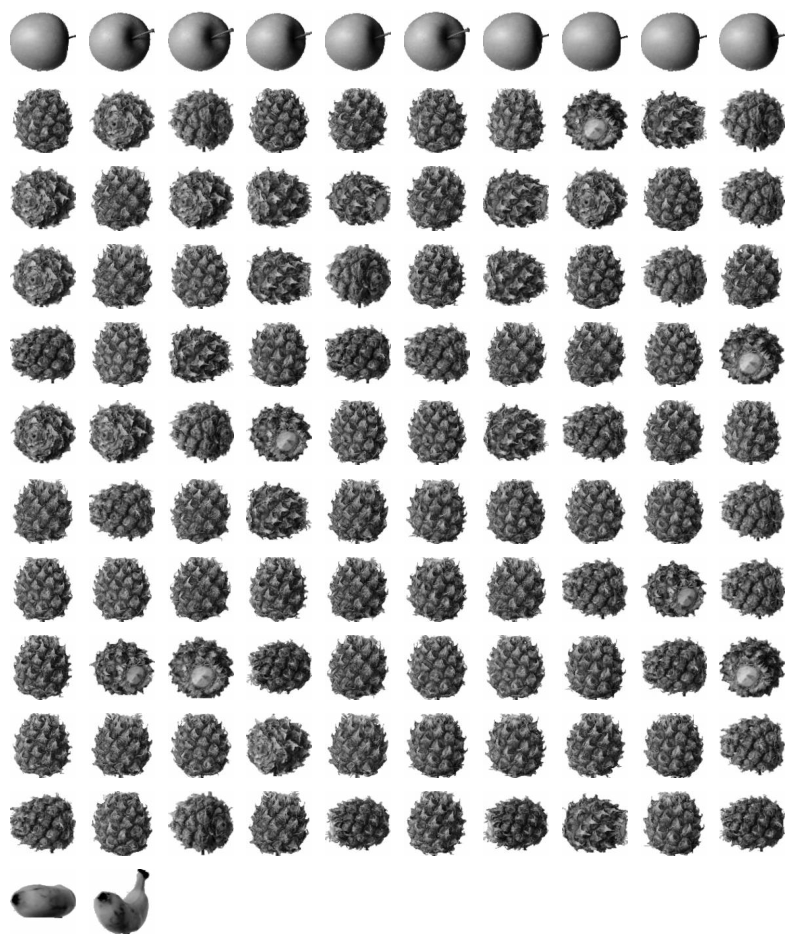

In [13]:
draw_fruits(fruits[km.labels_==0])

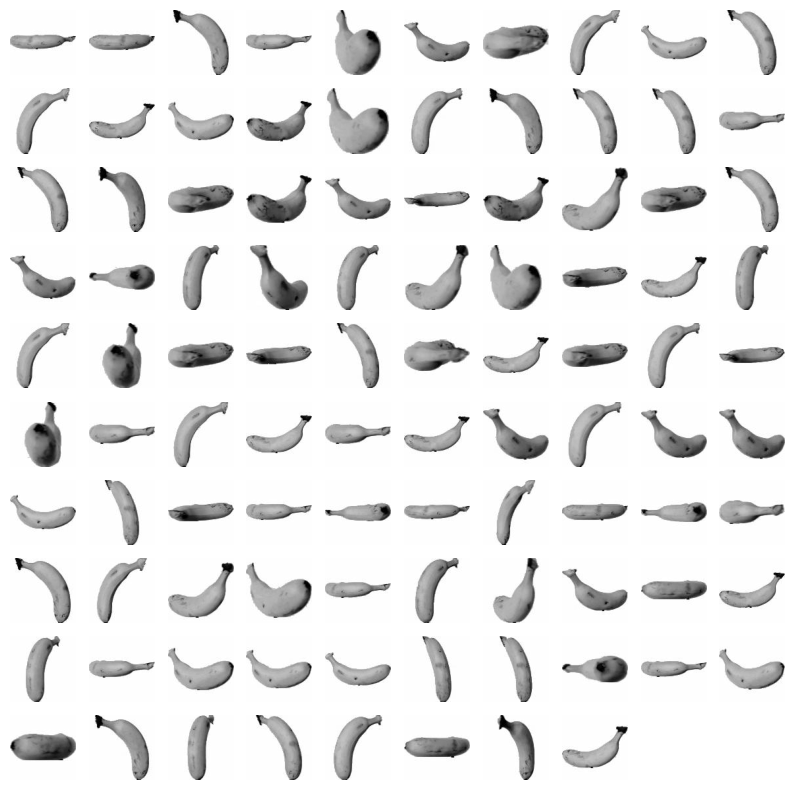

In [15]:
draw_fruits(fruits[km.labels_==1])

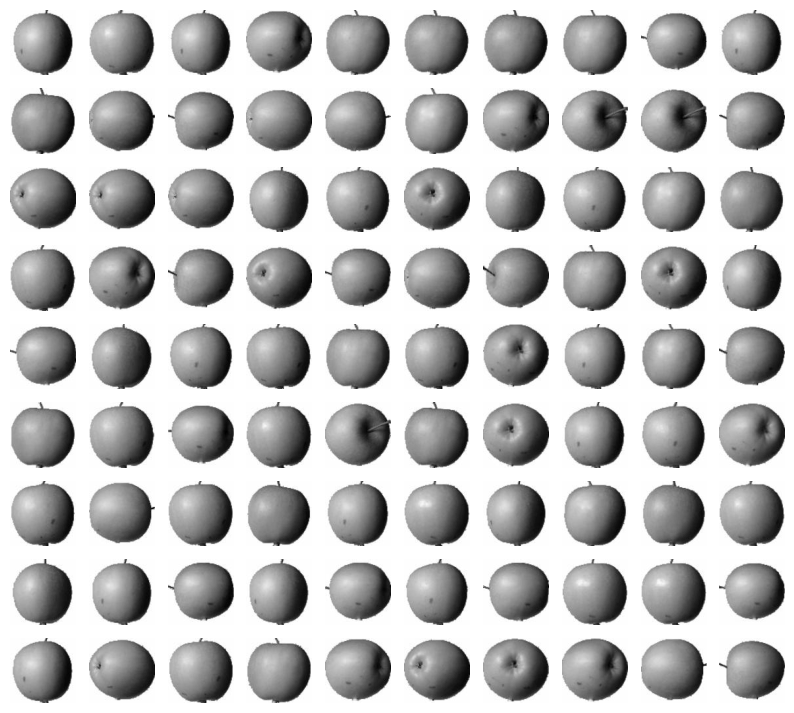

In [16]:
draw_fruits(fruits[km.labels_==2])

> 0 : 파인애플, 1: 바나나, 2: 사과

---
#### 클러스터 중심

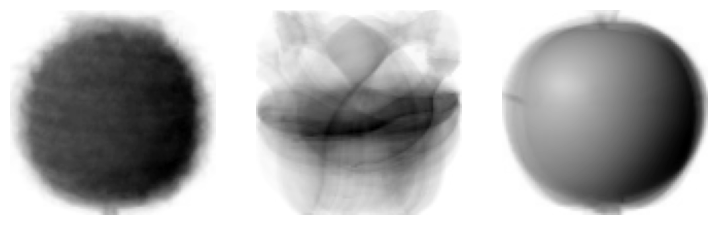

In [18]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100),ratio = 3)

In [ ]:
# 100번재의 클러스터 중심
km.transform(fruits_2d[100:101]) # 수치가 적은 가까운 값이 예측값

array([[3380.51439918, 8823.8971254 , 5263.87598253]])

In [21]:
# 100번째의 예측 군집값
km.predict(fruits_2d[100:101])

array([0], dtype=int32)

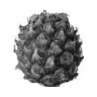

In [22]:
# 그림으로 확인
draw_fruits(fruits[100:101])

In [23]:
# 현 k-means 반복 횟수
km.n_iter_

4

----
### 최적의 k찾기
: Elbow Method

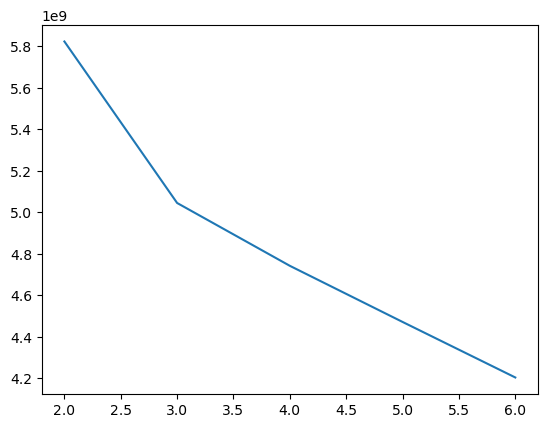

In [24]:
inertia = []
for k in range(2, 6+1):
  km = KMeans(n_clusters=k, random_state=42)
  km.fit(fruits_2d)
  inertia.append(km.inertia_)

plt.plot(range(2,6+1), inertia)
plt.show()